Using Colab cache for faster access to the 'retail-sales-dataset' dataset.
Dataset Path: /kaggle/input/retail-sales-dataset
['retail_sales_dataset.csv']

FIRST 5 ROWS
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):

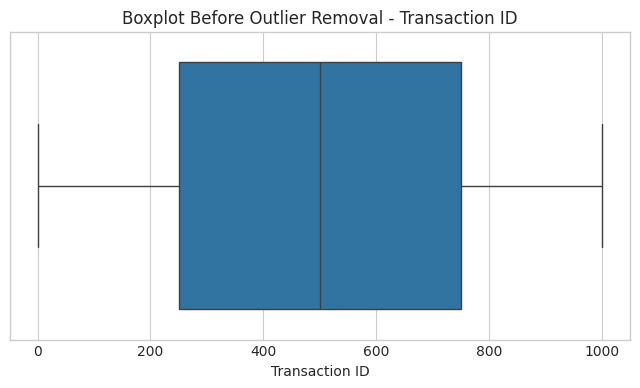


OUTLIERS REMOVED


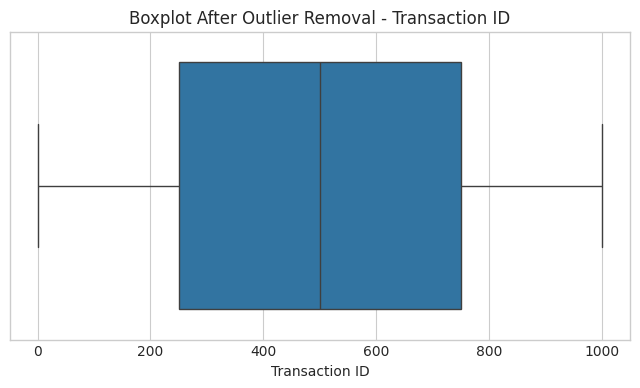

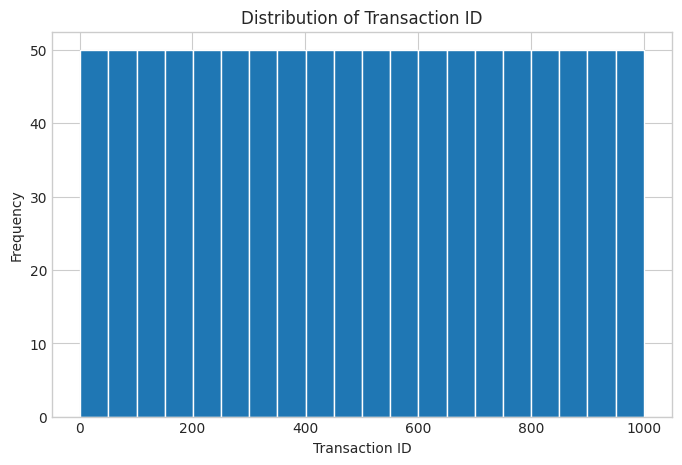

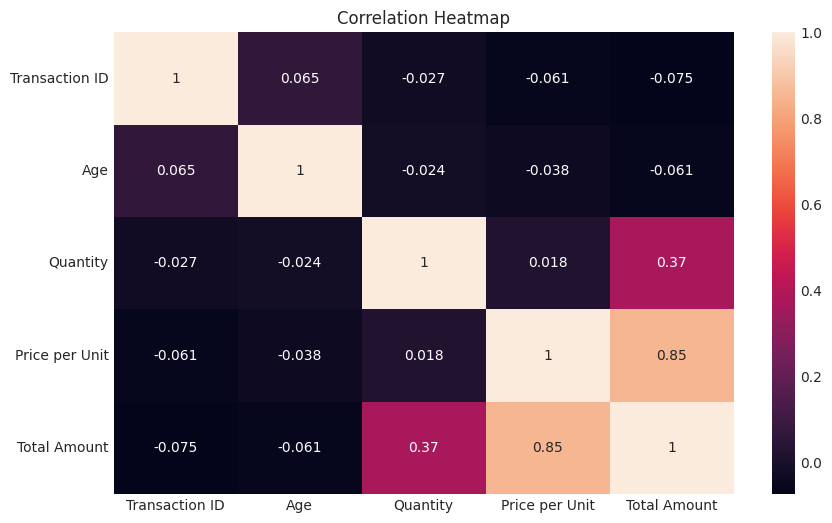

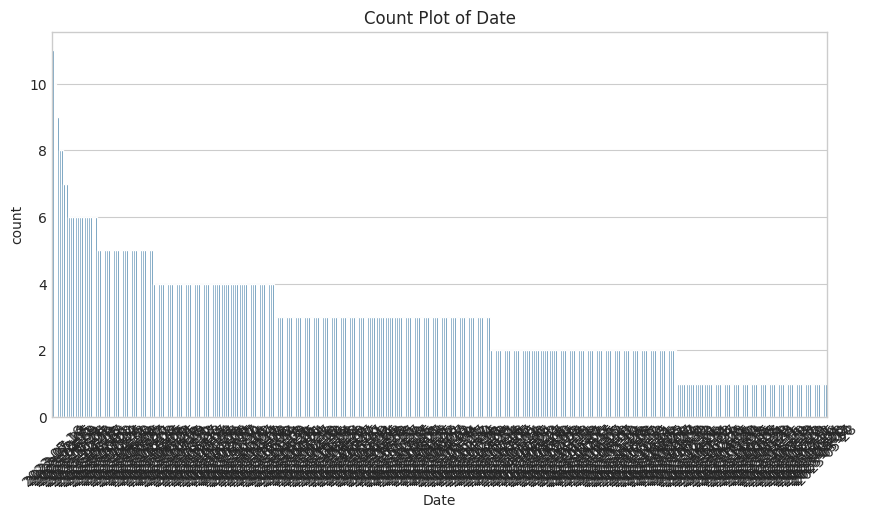

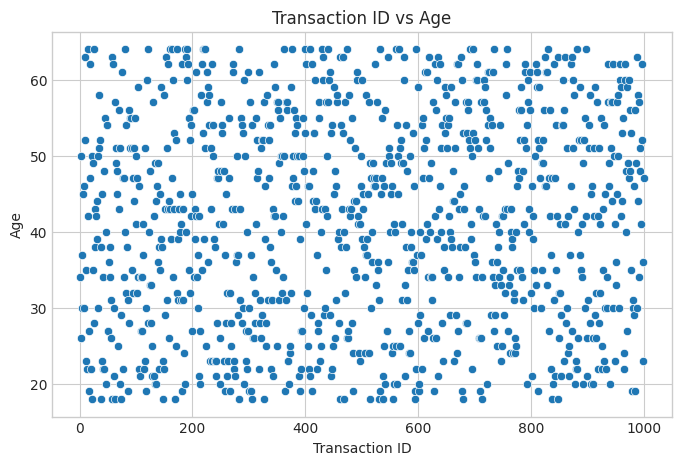

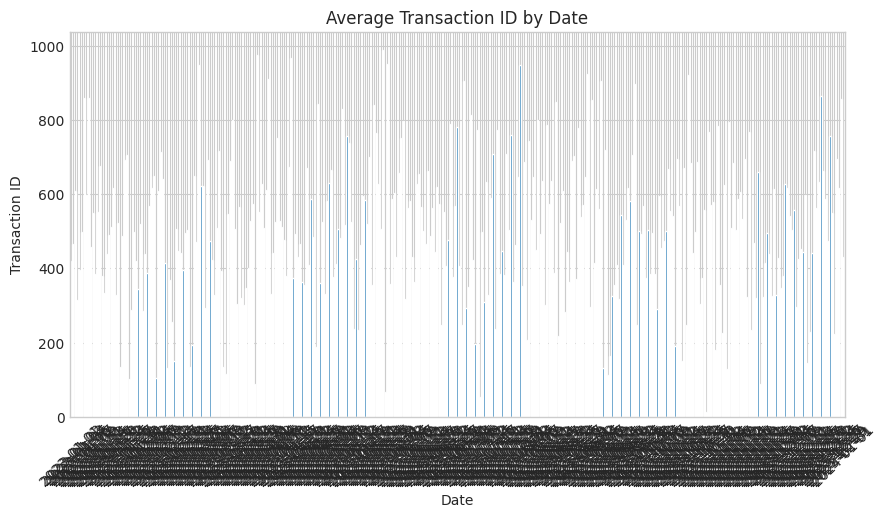


KEY FINDINGS / INSIGHTS

1. Dataset cleaned successfully
2. Missing values handled
3. Duplicate rows removed
4. Outliers removed using IQR method
5. Visualizations generated successfully
6. Correlation between numerical features analyzed


CLEANED DATASET SAVED


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


PROJECT COMPLETED SUCCESSFULLY


In [ ]:
# =========================================================
# RETAIL SALES DATA CLEANING & VISUALIZATION PROJECT
# Google Colab Runnable Code
# =========================================================

# -----------------------------
# STEP 1: INSTALL & IMPORT
# -----------------------------

!pip install kagglehub -q

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional settings
plt.rcParams['figure.figsize'] = (10,5)
sns.set_style("whitegrid")

# -----------------------------
# STEP 2: DOWNLOAD DATASET
# -----------------------------

path = kagglehub.dataset_download(
    "mohammadtalib786/retail-sales-dataset"
)

print("Dataset Path:", path)

# -----------------------------
# STEP 3: LOAD DATASET
# -----------------------------

import os

# Check files inside dataset folder
print(os.listdir(path))

# Replace filename if needed
file_path = os.path.join(path, os.listdir(path)[0])

df = pd.read_csv(file_path)

# -----------------------------
# STEP 4: BASIC DATA ANALYSIS
# -----------------------------

print("\nFIRST 5 ROWS")
print(df.head())

print("\nDATASET INFO")
print(df.info())

print("\nSHAPE OF DATASET")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

print("\nSTATISTICAL SUMMARY")
print(df.describe())

# -----------------------------
# STEP 5: CHECK MISSING VALUES
# -----------------------------

print("\nMISSING VALUES")
print(df.isnull().sum())

# -----------------------------
# STEP 6: HANDLE MISSING VALUES
# -----------------------------

# Fill numerical columns with median
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMISSING VALUES AFTER CLEANING")
print(df.isnull().sum())

# -----------------------------
# STEP 7: REMOVE DUPLICATES
# -----------------------------

print("\nDUPLICATE ROWS:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("DUPLICATES REMOVED")

# -----------------------------
# STEP 8: CLEAN TEXT DATA
# -----------------------------

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

print("\nTEXT CLEANING COMPLETED")

# -----------------------------
# STEP 9: OUTLIER DETECTION
# -----------------------------

# Select one important numerical column
# Change column name if necessary

print("\nNUMERICAL COLUMNS:")
print(numerical_cols)

# Example target column
target_col = numerical_cols[0]

print("\nUSING COLUMN FOR OUTLIER DETECTION:", target_col)

# Boxplot before removing outliers
plt.figure(figsize=(8,4))
sns.boxplot(x=df[target_col])
plt.title(f'Boxplot Before Outlier Removal - {target_col}')
plt.show()

# IQR METHOD
Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Remove outliers
df = df[
    (df[target_col] >= lower_limit) &
    (df[target_col] <= upper_limit)
]

print("\nOUTLIERS REMOVED")

# Boxplot after removing outliers
plt.figure(figsize=(8,4))
sns.boxplot(x=df[target_col])
plt.title(f'Boxplot After Outlier Removal - {target_col}')
plt.show()

# -----------------------------
# STEP 10: DATA VISUALIZATION
# -----------------------------

# =====================================================
# DASHBOARD STYLE VISUAL REPORTS
# =====================================================

# ---------- HISTOGRAM ----------

plt.figure(figsize=(8,5))
plt.hist(df[target_col], bins=20)
plt.title(f'Distribution of {target_col}')
plt.xlabel(target_col)
plt.ylabel('Frequency')
plt.show()

# ---------- CORRELATION HEATMAP ----------

plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()

# ---------- COUNT PLOT ----------

if len(categorical_cols) > 0:

    cat_col = categorical_cols[0]

    plt.figure(figsize=(10,5))

    sns.countplot(
        x=df[cat_col],
        order=df[cat_col].value_counts().index
    )

    plt.title(f'Count Plot of {cat_col}')
    plt.xticks(rotation=45)

    plt.show()

# ---------- SCATTER PLOT ----------

if len(numerical_cols) >= 2:

    plt.figure(figsize=(8,5))

    sns.scatterplot(
        x=df[numerical_cols[0]],
        y=df[numerical_cols[1]]
    )

    plt.title(
        f'{numerical_cols[0]} vs {numerical_cols[1]}'
    )

    plt.show()

# ---------- BAR CHART ----------

if len(categorical_cols) > 0 and len(numerical_cols) > 0:

    group_data = df.groupby(cat_col)[target_col].mean()

    plt.figure(figsize=(10,5))

    group_data.plot(kind='bar')

    plt.title(f'Average {target_col} by {cat_col}')

    plt.ylabel(target_col)

    plt.xticks(rotation=45)

    plt.show()

# -----------------------------
# STEP 11: INSIGHTS
# -----------------------------

print("\n==============================")
print("KEY FINDINGS / INSIGHTS")
print("==============================")

print(f"""
1. Dataset cleaned successfully
2. Missing values handled
3. Duplicate rows removed
4. Outliers removed using IQR method
5. Visualizations generated successfully
6. Correlation between numerical features analyzed
""")

# -----------------------------
# STEP 12: SAVE CLEANED DATA
# -----------------------------

cleaned_file = "cleaned_retail_sales.csv"

df.to_csv(cleaned_file, index=False)

print("\nCLEANED DATASET SAVED")

# -----------------------------
# STEP 13: DOWNLOAD CLEANED FILE
# -----------------------------

from google.colab import files

files.download(cleaned_file)

print("\nPROJECT COMPLETED SUCCESSFULLY")

DataFrame 'df' not found in memory. Attempting to load from 'cleaned_retail_sales.csv'...
File 'cleaned_retail_sales.csv' not found. Regenerating data from source...
Regenerating cleaned data from source...


100%|██████████| 11.2k/11.2k [00:00<00:00, 5.16MB/s]

Extracting files...
Raw DataFrame loaded.
Missing values handled.
Duplicates removed.
Text cleaning completed.
Outliers removed based on 'Transaction ID'.
Cleaned data regenerated and saved to 'cleaned_retail_sales.csv'.

AVAILABLE COLUMNS:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

TARGET COLUMN: Total Amount

Dropping non-numeric columns from features: ['Date', 'Customer ID', 'Gender', 'Product Category']

TRAINING DATA SIZE: (800, 4)
TESTING DATA SIZE: (200, 4)



/tmp/ipykernel_1004/2935149327.py:57: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_1004/2935149327.py:60: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try


MODEL TRAINED SUCCESSFULLY

MODEL ACCURACY: 1.0

CONFUSION MATRIX
[[10  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  7  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  9  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  8  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  9  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 23  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  7  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  9  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 17  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 15  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  8  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  5  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 14  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 12  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 10  0  0]
 [ 0  0  0  0  0  0  

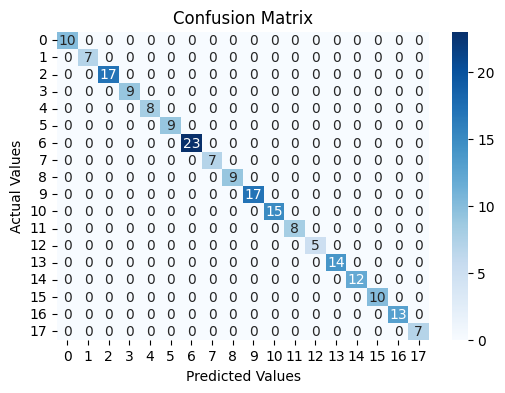


CLASSIFICATION REPORT
              precision    recall  f1-score   support

          25       1.00      1.00      1.00        10
          30       1.00      1.00      1.00         7
          50       1.00      1.00      1.00        17
          60       1.00      1.00      1.00         9
          75       1.00      1.00      1.00         8
          90       1.00      1.00      1.00         9
         100       1.00      1.00      1.00        23
         120       1.00      1.00      1.00         7
         150       1.00      1.00      1.00         9
         200       1.00      1.00      1.00        17
         300       1.00      1.00      1.00        15
         500       1.00      1.00      1.00         8
         600       1.00      1.00      1.00         5
         900       1.00      1.00      1.00        14
        1000       1.00      1.00      1.00        12
        1200       1.00      1.00      1.00        10
        1500       1.00      1.00      1.00        13
    

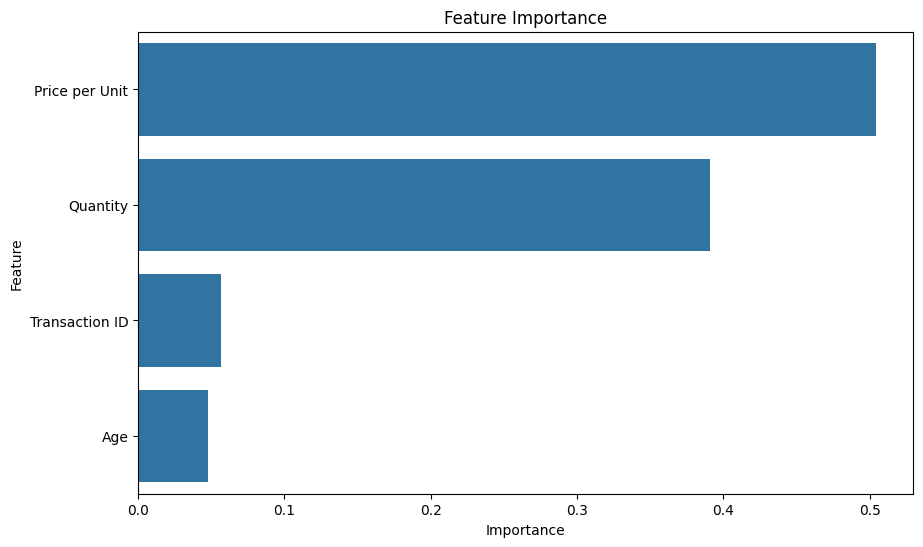


TEST DATASET OUTPUT SAVED


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


PROJECT COMPLETED SUCCESSFULLY

Outputs Generated:
1. Test Dataset Predictions CSV
2. Confusion Matrix
3. ROC Curve
4. Feature Importance Chart
5. Accuracy Score
6. Classification Report



In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import os # Added for path and file existence checks
import kagglehub # Added for data download if needed

# --- Start of robustness block for df and cleaned_retail_sales.csv ---
# This block ensures 'df' is loaded and 'cleaned_retail_sales.csv' exists,
# by recreating it if necessary. This handles NameError for df and FileNotFoundError for the CSV.

df_available = False
try:
    # Check if df is already defined in the current session
    _ = df # Attempt to access df; if NameError, it's not defined
    df_available = True
    print("DataFrame 'df' is already available in memory.")
except NameError:
    print("DataFrame 'df' not found in memory. Attempting to load from 'cleaned_retail_sales.csv'...")

if not df_available:
    if os.path.exists("cleaned_retail_sales.csv"):
        try:
            df = pd.read_csv("cleaned_retail_sales.csv")
            df_available = True
            print("DataFrame 'df' loaded successfully from 'cleaned_retail_sales.csv'.")
        except Exception as e:
            print(f"Error loading 'cleaned_retail_sales.csv': {e}. Regenerating data from source...")
            df_available = False # Loading failed, proceed to regenerate
    else:
        print("File 'cleaned_retail_sales.csv' not found. Regenerating data from source...")

if not df_available:
    # These steps are copied from the previous cell 'wOme77RCyNE8' to recreate the cleaned df
    print("Regenerating cleaned data from source...")
    # Ensure kagglehub is installed for data download
    !pip install kagglehub -q

    # Download dataset
    path = kagglehub.dataset_download("mohammadtalib786/retail-sales-dataset")

    # Load raw dataset
    file_path = os.path.join(path, os.listdir(path)[0])
    df = pd.read_csv(file_path)
    print("Raw DataFrame loaded.")

    # Re-identify column types after initial load for cleaning steps
    numerical_cols = df.select_dtypes(include=np.number).columns
    categorical_cols = df.select_dtypes(include='object').columns

    # Handle missing values - numerical with median
    for col in numerical_cols:
        df[col].fillna(df[col].median(), inplace=True)
    # Handle missing values - categorical with mode
    for col in categorical_cols:
        df[col].fillna(df[col].mode()[0], inplace=True)
    print("Missing values handled.")

    # Remove duplicates
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")

    # Clean text data
    for col in categorical_cols:
        df[col] = df[col].astype(str).str.strip().str.lower()
    print("Text cleaning completed.")

    # Outlier detection (replicating logic from wOme77RCyNE8)
    # wOme77RCyNE8 used numerical_cols[0] which was 'Transaction ID' for outlier detection.
    if len(numerical_cols) > 0:
        target_col_outlier = numerical_cols[0] # This will be 'Transaction ID' based on wOme77RCyNE8
        Q1 = df[target_col_outlier].quantile(0.25)
        Q3 = df[target_col_outlier].quantile(0.75)
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR
        df = df[
            (df[target_col_outlier] >= lower_limit) &
            (df[target_col_outlier] <= upper_limit)
        ]
        print(f"Outliers removed based on '{target_col_outlier}'.")
    else:
        print("No numerical columns found for outlier removal.")

    # Save the regenerated cleaned data for future use by this cell or subsequent runs
    cleaned_file = "cleaned_retail_sales.csv"
    df.to_csv(cleaned_file, index=False)
    print(f"Cleaned data regenerated and saved to '{cleaned_file}'.")
# --- End of robustness block ---

# STEP 8 — SELECT TARGET COLUMN
# ============================================================

print("\nAVAILABLE COLUMNS:")
print(df.columns)

# ============================================================
# CHANGE TARGET COLUMN HERE
# Example:
# target_column = "Purchased"
# ============================================================

target_column = df.columns[-1]

print("\nTARGET COLUMN:", target_column)

# ============================================================
# STEP 9 — FEATURE SELECTION
# ============================================================

X = df.drop(target_column, axis=1)
y = df[target_column]

# Identify non-numeric columns in X and drop them
non_numeric_cols = X.select_dtypes(include=['object', 'datetime64']).columns
if len(non_numeric_cols) > 0:
    print(f"\nDropping non-numeric columns from features: {list(non_numeric_cols)}")
    X = X.drop(columns=non_numeric_cols)

# ============================================================
# STEP 10 — TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTRAINING DATA SIZE:", X_train.shape)
print("TESTING DATA SIZE:", X_test.shape)

# ============================================================
# STEP 11 — BUILD MODEL
# ============================================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# ============================================================
# STEP 12 — TRAIN MODEL
# ============================================================

model.fit(X_train, y_train)

print("\nMODEL TRAINED SUCCESSFULLY")

# ============================================================
# STEP 13 — TEST MODEL USING TEST DATASET
# ============================================================

y_pred = model.predict(X_test)

# ============================================================
# STEP 14 — ACCURACY SCORE
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nMODEL ACCURACY:", accuracy)

# ============================================================
# STEP 15 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\nCONFUSION MATRIX")
print(cm)

# ============================================================
# STEP 16 — VISUALIZE CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

plt.savefig("confusion_matrix.png")

plt.show()

# ============================================================
# STEP 17 — CLASSIFICATION REPORT
# ============================================================

print("\nCLASSIFICATION REPORT")

print(classification_report(y_test, y_pred))

# ============================================================
# STEP 18 — ROC CURVE
# ============================================================

# Works for binary classification

if len(np.unique(y)) == 2:

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    auc_score = roc_auc_score(y_test, y_prob)

    plt.figure(figsize=(6,4))

    plt.plot(
        fpr,
        tpr,
        label=f"AUC Score = {auc_score:.2f}"
    )

    plt.plot([0,1], [0,1], linestyle='--')

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve")

    plt.legend()

    plt.savefig("roc_curve.png")

    plt.show()

# ============================================================
# STEP 19 — FEATURE IMPORTANCE
# ============================================================

importance = model.feature_importances_

feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nFEATURE IMPORTANCE")
print(feature_df)

# ============================================================
# STEP 20 — VISUALIZE FEATURE IMPORTANCE
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df
)

plt.title("Feature Importance")

plt.savefig("feature_importance.png")

plt.show()

# ============================================================
# STEP 21 — SAVE TEST DATASET OUTPUT
# ============================================================

test_output = X_test.copy()

test_output["Actual"] = y_test.values

test_output["Predicted"] = y_pred

test_output.to_csv(
    "test_dataset_predictions.csv",
    index=False
)

print("\nTEST DATASET OUTPUT SAVED")

# ============================================================
# STEP 22 — DOWNLOAD OUTPUT FILES
# ============================================================


files.download("test_dataset_predictions.csv")

files.download("confusion_matrix.png")

if len(np.unique(y)) == 2:
    files.download("roc_curve.png")

files.download("feature_importance.png")

# ============================================================
# STEP 23 — FINAL SUMMARY
# ============================================================

print("\n===================================")
print("PROJECT COMPLETED SUCCESSFULLY")
print("===================================")

print("""
Outputs Generated:
1. Test Dataset Predictions CSV
2. Confusion Matrix
3. ROC Curve
4. Feature Importance Chart
5. Accuracy Score
6. Classification Report
""")


FIRST 5 ROWS
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     cust001    male   34           beauty   
1               2  2023-02-27     cust002  female   26         clothing   
2               3  2023-01-13     cust003    male   50      electronics   
3               4  2023-05-21     cust004    male   37         clothing   
4               5  2023-05-06     cust005    male   30           beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  

DATASET SHAPE
(1000, 9)

COLUMN NAMES
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

DATA TYPES
Transaction ID       int64
Date                object
Custo

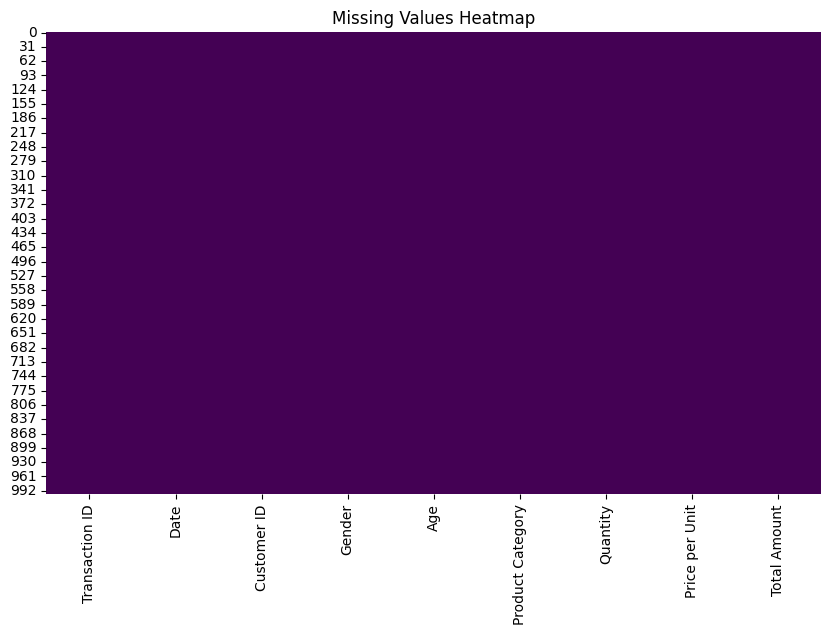

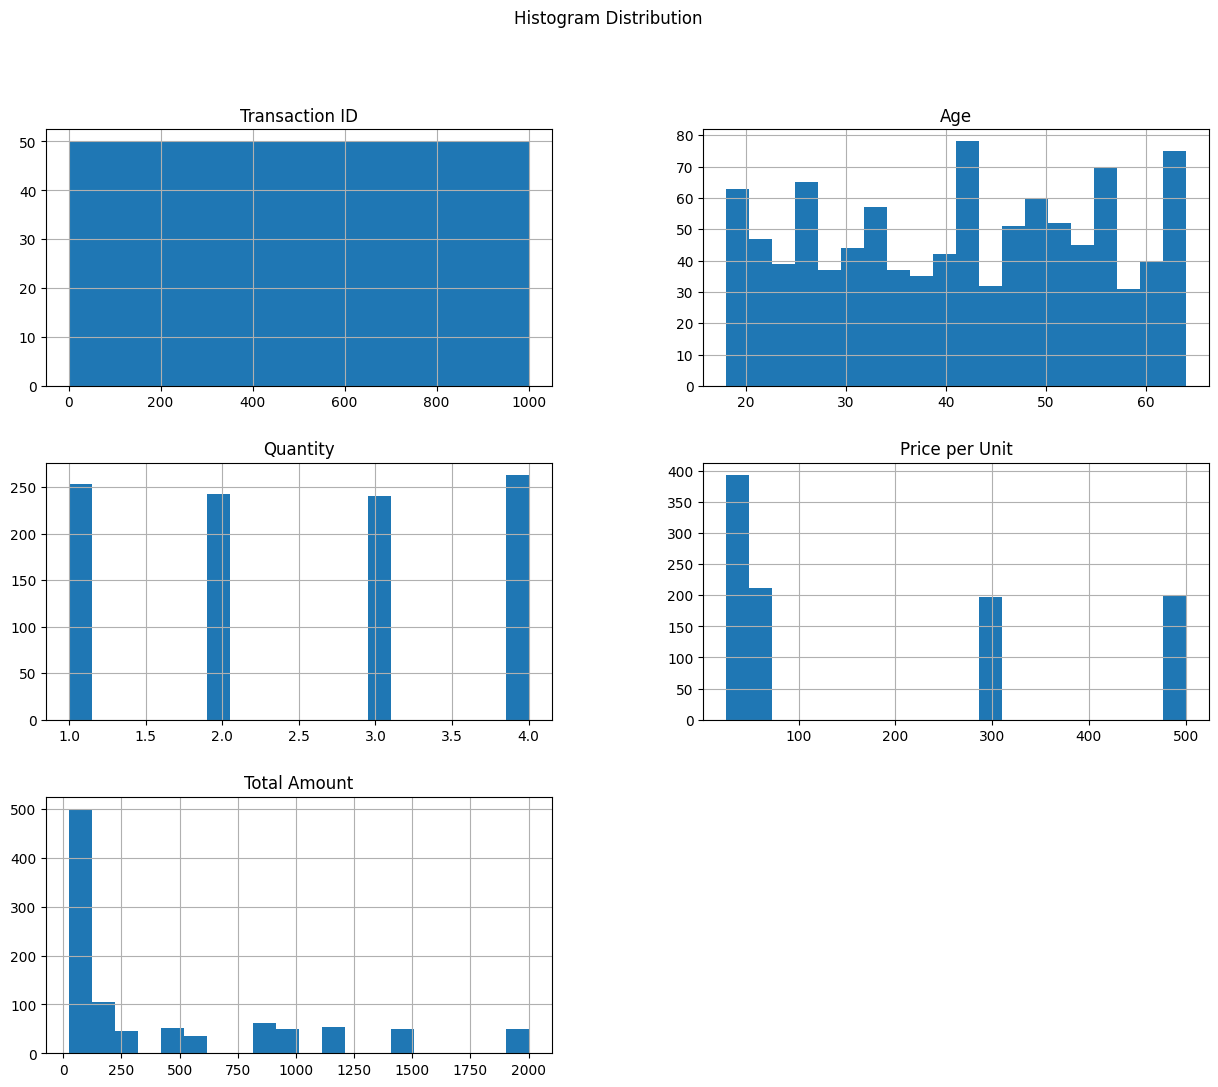

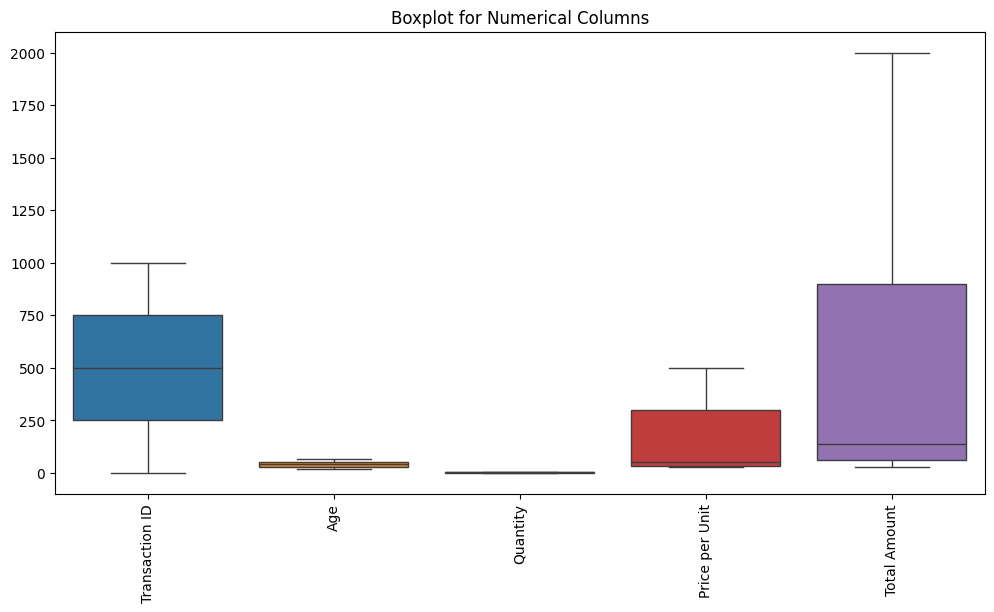


CORRELATION MATRIX
                Transaction ID       Age  Quantity  Price per Unit  \
Transaction ID        1.000000  0.065191 -0.026623       -0.060837   
Age                   0.065191  1.000000 -0.023737       -0.038423   
Quantity             -0.026623 -0.023737  1.000000        0.017501   
Price per Unit       -0.060837 -0.038423  0.017501        1.000000   
Total Amount         -0.075034 -0.060568  0.373707        0.851925   

                Total Amount  
Transaction ID     -0.075034  
Age                -0.060568  
Quantity            0.373707  
Price per Unit      0.851925  
Total Amount        1.000000  


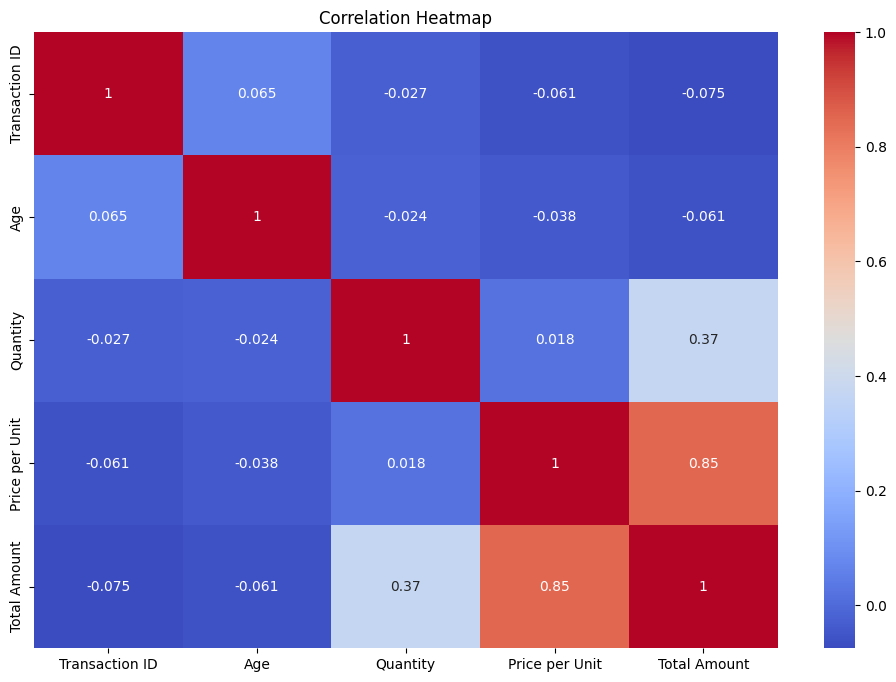

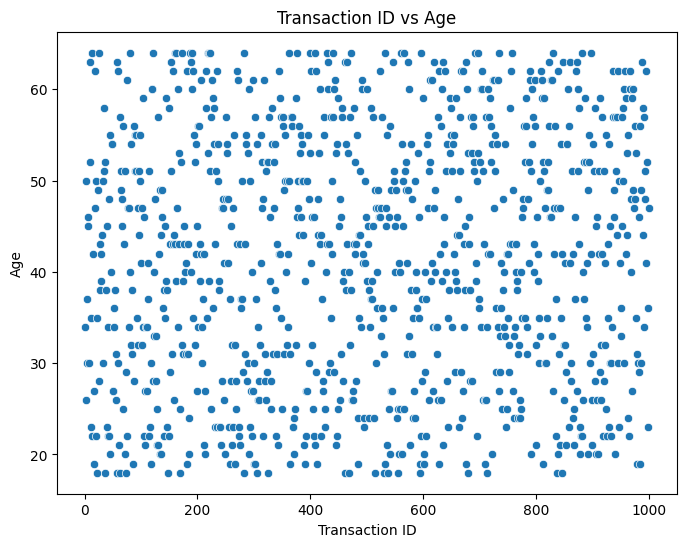

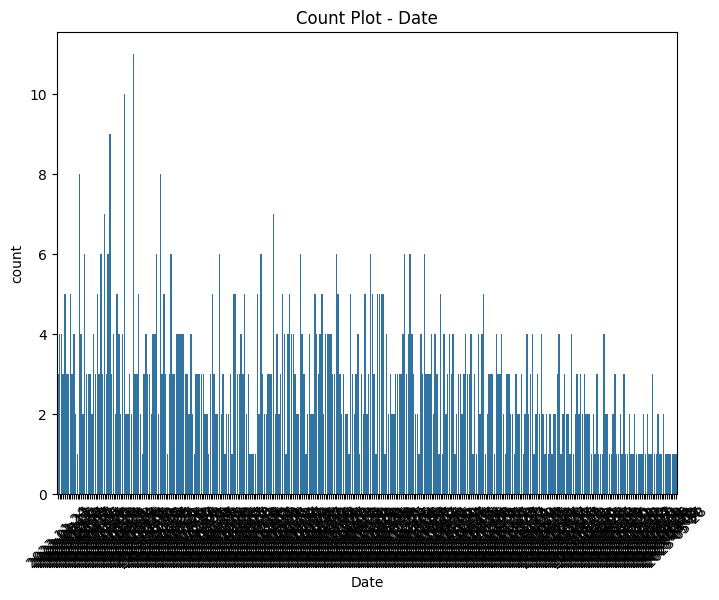


GROUP ANALYSIS
Date
2023-01-01    420.333333
2023-01-02    466.500000
2023-01-03    610.000000
2023-01-04    315.333333
2023-01-05    396.666667
                 ...    
2023-12-27    224.000000
2023-12-28    694.000000
2023-12-29    616.500000
2023-12-31    857.000000
2024-01-01    430.500000
Name: Transaction ID, Length: 345, dtype: float64

STRONG CORRELATIONS
Total Amount    Price per Unit    0.851925
Price per Unit  Total Amount      0.851925
dtype: float64

EDA REPORT GENERATED


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


EDA PROJECT COMPLETED SUCCESSFULLY

Outputs Generated:
1. Missing Values Heatmap
2. Histogram Distribution
3. Boxplot for Outliers
4. Correlation Heatmap
5. Scatter Plot
6. Count Plot
7. EDA Report



In [4]:
# ============================================================
# EDA ADDITIONAL CODE
# ADD THIS AFTER YOUR DATA CLEANING SECTION
# ============================================================

# ============================================================
# STEP — BASIC DATA UNDERSTANDING
# ============================================================

print("\nFIRST 5 ROWS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

print("\nDATA TYPES")
print(df.dtypes)

print("\nSTATISTICAL SUMMARY")
print(df.describe())

# ============================================================
# STEP — MISSING VALUES VISUALIZATION
# ============================================================

plt.figure(figsize=(10,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap")

plt.savefig("missing_values_heatmap.png")

plt.show()

# ============================================================
# STEP — HISTOGRAM DISTRIBUTION
# ============================================================

df.hist(
    figsize=(15,12),
    bins=20
)

plt.suptitle("Histogram Distribution")

plt.savefig("histogram_distribution.png")

plt.show()

# ============================================================
# STEP — BOXPLOT FOR OUTLIERS
# ============================================================

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df[numerical_cols]
)

plt.xticks(rotation=90)

plt.title("Boxplot for Numerical Columns")

plt.savefig("boxplot_outliers.png")

plt.show()

# ============================================================
# STEP — CORRELATION ANALYSIS
# ============================================================

correlation_matrix = df.corr(
    numeric_only=True
)

print("\nCORRELATION MATRIX")

print(correlation_matrix)

# ============================================================
# STEP — CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png")

plt.show()

# ============================================================
# STEP — SCATTER PLOT
# ============================================================

if len(numerical_cols) >= 2:

    plt.figure(figsize=(8,6))

    sns.scatterplot(
        x=numerical_cols[0],
        y=numerical_cols[1],
        data=df
    )

    plt.title(
        f"{numerical_cols[0]} vs {numerical_cols[1]}"
    )

    plt.savefig("scatter_plot.png")

    plt.show()

# ============================================================
# STEP — COUNT PLOT
# ============================================================

if len(categorical_cols) > 0:

    plt.figure(figsize=(8,6))

    sns.countplot(
        x=df[categorical_cols[0]]
    )

    plt.xticks(rotation=45)

    plt.title(
        f"Count Plot - {categorical_cols[0]}"
    )

    plt.savefig("count_plot.png")

    plt.show()

# ============================================================
# STEP — GROUP ANALYSIS
# ============================================================

if (
    len(categorical_cols) > 0 and
    len(numerical_cols) > 0
):

    group_analysis = df.groupby(
        categorical_cols[0]
    )[numerical_cols[0]].mean()

    print("\nGROUP ANALYSIS")

    print(group_analysis)

# ============================================================
# STEP — STRONG CORRELATION ANALYSIS
# ============================================================

print("\nSTRONG CORRELATIONS")

corr_pairs = correlation_matrix.unstack()

corr_pairs = corr_pairs.sort_values(
    kind="quicksort"
)

strong_corr = corr_pairs[
    (corr_pairs > 0.7) &
    (corr_pairs < 1.0)
]

print(strong_corr)

# ============================================================
# STEP — GENERATE EDA REPORT
# ============================================================

report = f"""
====================================================
EXPLORATORY DATA ANALYSIS REPORT
====================================================

1. DATASET OVERVIEW
-------------------
Rows: {df.shape[0]}
Columns: {df.shape[1]}

2. DATA CLEANING
----------------
- Missing values handled
- Duplicates removed
- Text standardized
- Outliers removed

3. ANALYSIS PERFORMED
---------------------
- Statistical Summary
- Missing Value Analysis
- Histogram Distribution
- Boxplot Analysis
- Correlation Analysis
- Scatter Plot Analysis
- Count Plot Analysis
- Group Analysis

4. KEY INSIGHTS
----------------
- Strong correlations identified
- Data distributions analyzed
- Outliers detected and removed
- Relationships between variables explored

====================================================
EDA PROJECT COMPLETED SUCCESSFULLY
====================================================
"""

with open(
    "EDA_Report.txt",
    "w"
) as file:

    file.write(report)

print("\nEDA REPORT GENERATED")

# ============================================================
# STEP — DOWNLOAD OUTPUT FILES
# ============================================================

from google.colab import files

files.download("missing_values_heatmap.png")

files.download("histogram_distribution.png")

files.download("boxplot_outliers.png")

files.download("correlation_heatmap.png")

files.download("scatter_plot.png")

files.download("count_plot.png")

files.download("EDA_Report.txt")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n===================================")
print("EDA PROJECT COMPLETED SUCCESSFULLY")
print("===================================")

print("""
Outputs Generated:
1. Missing Values Heatmap
2. Histogram Distribution
3. Boxplot for Outliers
4. Correlation Heatmap
5. Scatter Plot
6. Count Plot
7. EDA Report
""")